# VAE Training Notebook — FP32 Precision

This notebook trains any model registered in `MODEL_REGISTRY` using standard FP32 precision.  
Swap `MODEL_KEY` below and everything adapts.

1-Setup and Imports to adjust your root directory location

2-Configuration to select between models and choose hyperparams

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1 — Setup & Imports

In [ ]:
import sys, os, time, json
from pathlib import Path

import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Adjust this path if running from a different location.
PROJECT_ROOT = Path('/content/drive/MyDrive/Bayes_Project')  # assumes notebook is in train/
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f'Project root: {PROJECT_ROOT}')
print(f'PyTorch:      {torch.__version__}')
print(f'CUDA:         {torch.cuda.is_available()}')


Project root: /content/drive/MyDrive/Bayes_Project
PyTorch:      2.10.0+cu128
CUDA:         True


In [ ]:
from data.dataloader import get_dataloaders, IMAGE_SIZE
from models.base import get_model, MODEL_REGISTRY

# Import model modules
import models.vae  # noqa: F401
import models.conv_vae  # noqa: F401
import models.vq_vae    # noqa: F401

from train.train_utils import (
    MetricTracker,
    RunLog,
    Timer,
    compute_image_metrics,
    save_checkpoint,
    load_checkpoint,
)
from outputs.plotting import (
    plot_loss,
    plot_all_metrics,
    plot_reconstructions,
    plot_samples,
)

print('Available models:', list(MODEL_REGISTRY.keys()))


Available models: ['vae', 'conv_vae', 'vq_vae']


## 2 — Configuration

All hyperparameters to be tuned here

In [ ]:

# Model
MODEL_KEY       = 'conv_vae'           # 'vae' | 'conv_vae' | 'vq_vae'
LATENT_DIM      = 64
HIDDEN_DIMS     = [128, 256]          # linear VAE: neuron counts  e.g. [512, 256, 256, 128]
                                     # conv VAE:  channel counts e.g. [32, 64, 128, 256]
KL_WEIGHT       = 1.0                # beta > 1 → beta-VAE
RECON_LOSS_TYPE = 'mse'              # 'bce' or 'mse'

# VQ-VAE specific (ignored by other models)
NUM_EMBEDDINGS  = 1024            # codebook size K
COMMITMENT_COST = 0.25             # beta on commitment loss
USE_EMA         = True             # EMA codebook updates
EMA_DECAY       = 0.99

# Data
DATASET         = 'mnist'         # 'mnist' | 'fashion_mnist' | 'cifar10'
BATCH_SIZE      = 128
NUM_WORKERS     = 2
DATA_ROOT       = str(PROJECT_ROOT / 'data' / 'raw')

# Training
EPOCHS          = 50
LR              = 3e-4
WEIGHT_DECAY    = 1e-5
SCHEDULER_TYPE  = 'none'          # 'none' | 'cosine' | 'step', not tested
STEP_SIZE       = 20              # only for 'step', not tested
GAMMA           = 0.5             # only for 'step', not tested
PRECISION       = 'fp32'          # label for the run log
KL_ANNEAL_EPOCHS = 20

# Logging
CHECKPOINT_DIR  = str(PROJECT_ROOT / 'models' / 'checkpoints')
LOG_DIR         = str(PROJECT_ROOT / 'logs')
OUTPUT_DIR      = str(PROJECT_ROOT / 'outputs')
SAVE_EVERY      = 0              # epoch interval; 0 = only best & final
RUN_NAME        = "conv_vae_mnist"            # auto-generated if None

# Others
SEED            = 42
DEVICE          = None            # None = auto-detect


## 3 — Device & Seed

In [ ]:
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if DEVICE:
    device = torch.device(DEVICE)
elif torch.cuda.is_available():
    device = torch.device('cuda')
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print(f'Device: {device}')


Device: cuda


## 4 — Data

In [ ]:
train_loader, test_loader, channels = get_dataloaders(
    dataset_name=DATASET,
    batch_size=BATCH_SIZE,
    data_root=DATA_ROOT,
    num_workers=NUM_WORKERS,
)

print(f'Dataset:      {DATASET}')
print(f'Channels:     {channels}')
print(f'Train batches: {len(train_loader)}')
print(f'Test batches:  {len(test_loader)}')


Dataset:      mnist
Channels:     1
Train batches: 468
Test batches:  79


### Quick data preview

Batch shape: torch.Size([128, 1, 32, 32])  |  dtype: torch.float32
Pixel range:  [0.000, 1.000]


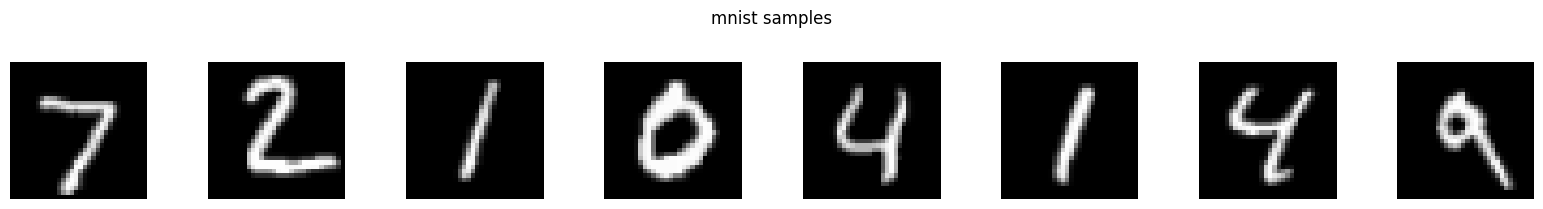

In [ ]:
sample_batch, sample_labels = next(iter(test_loader))
print(f'Batch shape: {sample_batch.shape}  |  dtype: {sample_batch.dtype}')
print(f'Pixel range:  [{sample_batch.min():.3f}, {sample_batch.max():.3f}]')

fig, axes = plt.subplots(1, 8, figsize=(16, 2))
for i in range(8):
    img = sample_batch[i]
    if img.shape[0] == 1:
        axes[i].imshow(img.squeeze(0), cmap='gray')
    else:
        axes[i].imshow(img.permute(1, 2, 0))
    axes[i].axis('off')
plt.suptitle(f'{DATASET} samples', y=1.02)
plt.tight_layout()
plt.show()


## 5 — Model

In [ ]:
model = get_model(
    MODEL_KEY,
    input_channels=channels,
    image_size=IMAGE_SIZE,
    hidden_dims=HIDDEN_DIMS,
    latent_dim=LATENT_DIM,
    kl_weight=KL_WEIGHT,
    recon_loss_type=RECON_LOSS_TYPE,
    # VQ-VAE specific (ignored by other models via **kwargs)
    num_embeddings=NUM_EMBEDDINGS,
    commitment_cost=COMMITMENT_COST,
    use_ema=USE_EMA,
    ema_decay=EMA_DECAY,
).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable   = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'Model:         {model.model_name}')
print(f'Total params:  {total_params:,}')
print(f'Trainable:     {trainable:,}')
print(f'Extra metrics: {model.extra_metrics}')
print(f'Latent dim:    {model.get_latent_dim()}')


Model:         conv_vae
Total params:  3,755,905
Trainable:     3,755,905
Extra metrics: []
Latent dim:    64


## 6 — Optimizer & Scheduler

In [ ]:
optimizer = torch.optim.Adam(
    model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY
)

scheduler = None
if SCHEDULER_TYPE == 'cosine':
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=EPOCHS
    )
elif SCHEDULER_TYPE == 'step':
    scheduler = torch.optim.lr_scheduler.StepLR(
        optimizer, step_size=STEP_SIZE, gamma=GAMMA
    )

print(f'Optimizer:  Adam (lr={LR}, wd={WEIGHT_DECAY})')
print(f'Scheduler:  {SCHEDULER_TYPE}')


Optimizer:  Adam (lr=0.0003, wd=1e-05)
Scheduler:  none


## 7 — Run Log Initialisation

In [ ]:
run_name = RUN_NAME or f'{model.model_name}_{DATASET}_z{LATENT_DIM}_{PRECISION}'

run_log = RunLog(
    model_name=model.model_name,
    dataset=DATASET,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    learning_rate=LR,
    latent_dim=LATENT_DIM,
    kl_weight=KL_WEIGHT,
    optimizer_name='Adam',
    scheduler_name=SCHEDULER_TYPE,
    precision=PRECISION,
    device=str(device),
    seed=SEED,
    extra_hparams={
        'hidden_dims': HIDDEN_DIMS,
        'recon_loss': RECON_LOSS_TYPE,
        'weight_decay': WEIGHT_DECAY,
        'num_embeddings': NUM_EMBEDDINGS,
        'commitment_cost': COMMITMENT_COST,
        'use_ema': USE_EMA,
    },
)

log_path  = Path(LOG_DIR) / f'{run_name}.json'
ckpt_dir  = Path(CHECKPOINT_DIR)
out_dir   = Path(OUTPUT_DIR)

for d in [log_path.parent, ckpt_dir, out_dir]:
    d.mkdir(parents=True, exist_ok=True)

print(f'Run name:    {run_name}')
print(f'Log path:    {log_path}')
print(f'Checkpoints: {ckpt_dir}')


Run name:    conv_vae_mnist
Log path:    /content/drive/MyDrive/Bayes_Project/logs/conv_vae_mnist.json
Checkpoints: /content/drive/MyDrive/Bayes_Project/models/checkpoints


## 8 — Training & Evaluation Functions

These are identical to `train_fp32.py` but defined here for notebook self-containment.

In [ ]:
def train_one_epoch(model, loader, optimizer, device, tracker):
    """Run one training epoch."""
    if KL_ANNEAL_EPOCHS > 0 and hasattr(model, 'kl_weight'):
        model.kl_weight = KL_WEIGHT * min(1.0, epoch / KL_ANNEAL_EPOCHS)

    model.train()
    for batch_data, _ in loader:
        batch_data = batch_data.to(device)
        batch_size = batch_data.size(0)

        # Forward
        model_output = model.forward(batch_data)
        loss_dict = model.loss_function(model_output, batch_data)
        total_loss = loss_dict['total_loss']

        # Backward
        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()

        # Metrics
        with torch.no_grad():
            recon = model_output['recon']
            img_metrics = compute_image_metrics(recon, batch_data)

        # Model-specific extras from forward output
        extra_dict = {
            k: model_output[k]
            for k in model.extra_metrics
            if k in model_output
        }

        tracker.update(loss_dict, img_metrics, extra_dict, batch_size)


@torch.no_grad()
def evaluate(model, loader, device, tracker):
    """Run evaluation on test set."""
    model.eval()
    for batch_data, _ in loader:
        batch_data = batch_data.to(device)
        batch_size = batch_data.size(0)

        model_output = model.forward(batch_data)
        loss_dict = model.loss_function(model_output, batch_data)

        recon = model_output['recon']
        img_metrics = compute_image_metrics(recon, batch_data)

        extra_dict = {
            k: model_output[k]
            for k in model.extra_metrics
            if k in model_output
        }

        tracker.update(loss_dict, img_metrics, extra_dict, batch_size)


In [ ]:
import gc
gc.collect()
torch.cuda.empty_cache()
print(f'Allocated: {torch.cuda.memory_allocated() / 1e9:.2f} GB')
print(f'Reserved:  {torch.cuda.memory_reserved() / 1e9:.2f} GB')

Allocated: 0.03 GB
Reserved:  0.06 GB


## 9 — Training Loop

**CHANGE POINT for mixed precision:**  
Wrap the forward + loss section inside `with torch.cuda.amp.autocast():` and use a `GradScaler`.

In [ ]:
timer = Timer()
timer.start()
best_loss = float('inf')

live_train_loss = []
live_val_loss   = []

print(f'Starting training for {EPOCHS} epochs …\n')

for epoch in range(1, EPOCHS + 1):

    # train
    train_tracker = MetricTracker(extra_keys=model.extra_metrics)
    train_one_epoch(model, train_loader, optimizer, device, train_tracker)
    train_summary = train_tracker.summarise()

    # evaluate
    eval_tracker = MetricTracker(extra_keys=model.extra_metrics)
    evaluate(model, test_loader, device, eval_tracker)
    eval_summary = eval_tracker.summarise()

    if scheduler is not None:
        scheduler.step()

    # record
    epoch_record = {
        'epoch': epoch,
        **{f'train_{k}': v for k, v in train_summary.items()},
        **{f'val_{k}': v for k, v in eval_summary.items()},
    }
    run_log.epoch_history.append(epoch_record)

    val_loss = eval_summary.get('total_loss', train_summary['total_loss'])
    live_train_loss.append(train_summary['total_loss'])
    live_val_loss.append(val_loss)

    lr_now = optimizer.param_groups[0]['lr']
    print(
        f'  Epoch {epoch:3d}/{EPOCHS}  |  '
        f'train_loss={train_summary["total_loss"]:.4f}  '
        f'val_loss={val_loss:.4f}  '
        f'psnr={eval_summary.get("psnr", 0):.2f}  '
        f'ssim={eval_summary.get("ssim", 0):.4f}  '
        f'lr={lr_now:.2e}'
    )

    # checkpoint
    is_best = val_loss < best_loss
    if is_best:
        best_loss = val_loss
        run_log.best_epoch = epoch
        run_log.best_total_loss = val_loss
        save_checkpoint(
            model, optimizer, epoch, eval_summary,
            ckpt_dir / f'{run_name}_best.pt',
            scheduler=scheduler,
        )

    if SAVE_EVERY > 0 and epoch % SAVE_EVERY == 0:
        save_checkpoint(
            model, optimizer, epoch, eval_summary,
            ckpt_dir / f'{run_name}_epoch{epoch}.pt',
            scheduler=scheduler,
        )

    # Periodic JSON save (crash safety)
    run_log.total_training_time_sec = timer.elapsed()
    run_log.save(log_path)

# final save
run_log.total_training_time_sec = timer.elapsed()
run_log.save(log_path)

save_checkpoint(
    model, optimizer, EPOCHS, eval_summary,
    ckpt_dir / f'{run_name}_final.pt',
    scheduler=scheduler,
)

print(f'\nFinished in {run_log.total_training_time_sec:.1f}s')
print(f'Best val_loss={run_log.best_total_loss:.4f} at epoch {run_log.best_epoch}')
print(f'Log: {log_path}')


Starting training for 50 epochs …

  Epoch   1/50  |  train_loss=60.2130  val_loss=40.0340  psnr=15.01  ssim=0.4032  lr=3.00e-04
  Epoch   2/50  |  train_loss=20.6958  val_loss=13.9313  psnr=22.35  ssim=0.7588  lr=3.00e-04
  Epoch   3/50  |  train_loss=18.3453  val_loss=16.2705  psnr=21.98  ssim=0.8372  lr=3.00e-04
  Epoch   4/50  |  train_loss=20.0219  val_loss=17.9565  psnr=21.28  ssim=0.8247  lr=3.00e-04
  Epoch   5/50  |  train_loss=21.2318  val_loss=19.0326  psnr=20.92  ssim=0.8169  lr=3.00e-04
  Epoch   6/50  |  train_loss=22.2269  val_loss=20.0312  psnr=20.67  ssim=0.8249  lr=3.00e-04
  Epoch   7/50  |  train_loss=23.1360  val_loss=21.0591  psnr=20.50  ssim=0.8354  lr=3.00e-04
  Epoch   8/50  |  train_loss=24.0141  val_loss=21.9465  psnr=20.21  ssim=0.8336  lr=3.00e-04
  Epoch   9/50  |  train_loss=24.9421  val_loss=22.9147  psnr=19.93  ssim=0.8304  lr=3.00e-04
  Epoch  10/50  |  train_loss=25.8320  val_loss=23.8319  psnr=19.82  ssim=0.8357  lr=3.00e-04
  Epoch  11/50  |  train_

## 10 — Live Loss Curve

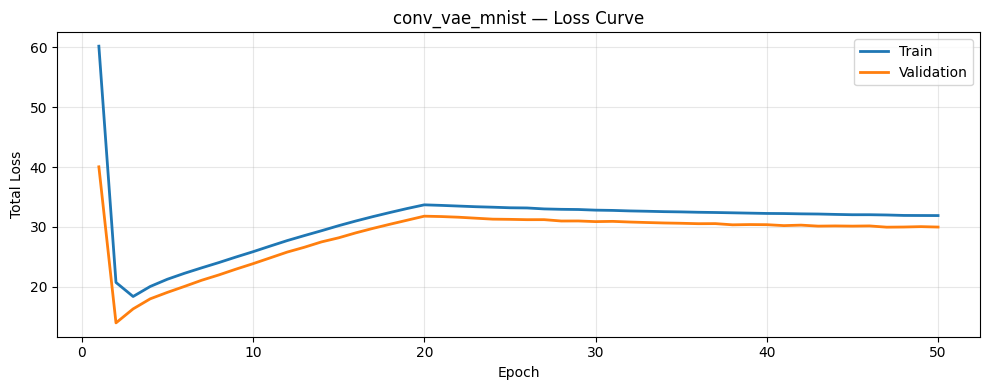

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
epochs_range = range(1, len(live_train_loss) + 1)
ax.plot(epochs_range, live_train_loss, label='Train', linewidth=2)
ax.plot(epochs_range, live_val_loss, label='Validation', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Total Loss')
ax.set_title(f'{run_name} — Loss Curve')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 11 — Detailed Metrics (from JSON log)

These use the plotting module, which reads the JSON and auto-detects all metrics  
(including any model-specific extras like codebook usage for VQ-VAE).

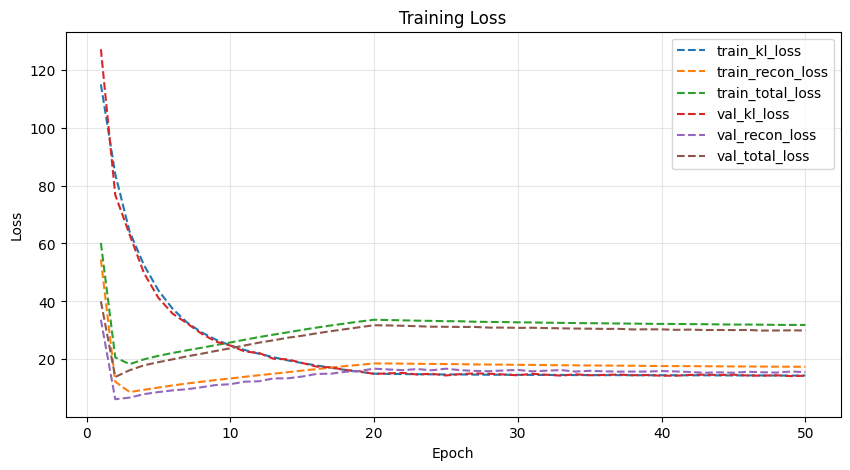

In [ ]:
# Loss breakdown (total, recon, kl, etc.)
plot_loss(log_path, save_path=out_dir / f'{run_name}_loss.png', show=True)


In [ ]:
# ── VQ-VAE specific: Codebook health ──────────────────────
if hasattr(model, 'quantizer'):
    run_data = run_log.epoch_history

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

    epochs_range = range(1, len(run_data) + 1)

    # Codebook usage (fraction of codes used per batch)
    usage = [ep.get('val_codebook_usage', 0) for ep in run_data]
    ax1.plot(epochs_range, usage, color='teal', linewidth=2)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Usage (fraction)')
    ax1.set_title('Codebook Usage')
    ax1.set_ylim(0, 1.05)
    ax1.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5, label='ideal')
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    # Perplexity (exp of entropy — higher = more uniform usage)
    perp = [ep.get('val_perplexity', 0) for ep in run_data]
    ax2.plot(epochs_range, perp, color='coral', linewidth=2)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Perplexity')
    ax2.set_title('Codebook Perplexity')
    ax2.axhline(y=NUM_EMBEDDINGS, color='gray', linestyle='--', alpha=0.5,
                label=f'max ({NUM_EMBEDDINGS})')
    ax2.grid(True, alpha=0.3)
    ax2.legend()

    fig.tight_layout()
    plt.show()

    # Summary
    print(f'Final codebook usage:  {usage[-1]:.1%}  ({int(usage[-1] * NUM_EMBEDDINGS)}/{NUM_EMBEDDINGS} codes active)')
    print(f'Final perplexity:      {perp[-1]:.1f}  (max possible: {NUM_EMBEDDINGS})')
else:
    print('Not a VQ-VAE model — skipping codebook diagnostics.')

Not a VQ-VAE model — skipping codebook diagnostics.


## 12 — Reconstructions (Ground Truth vs Model)

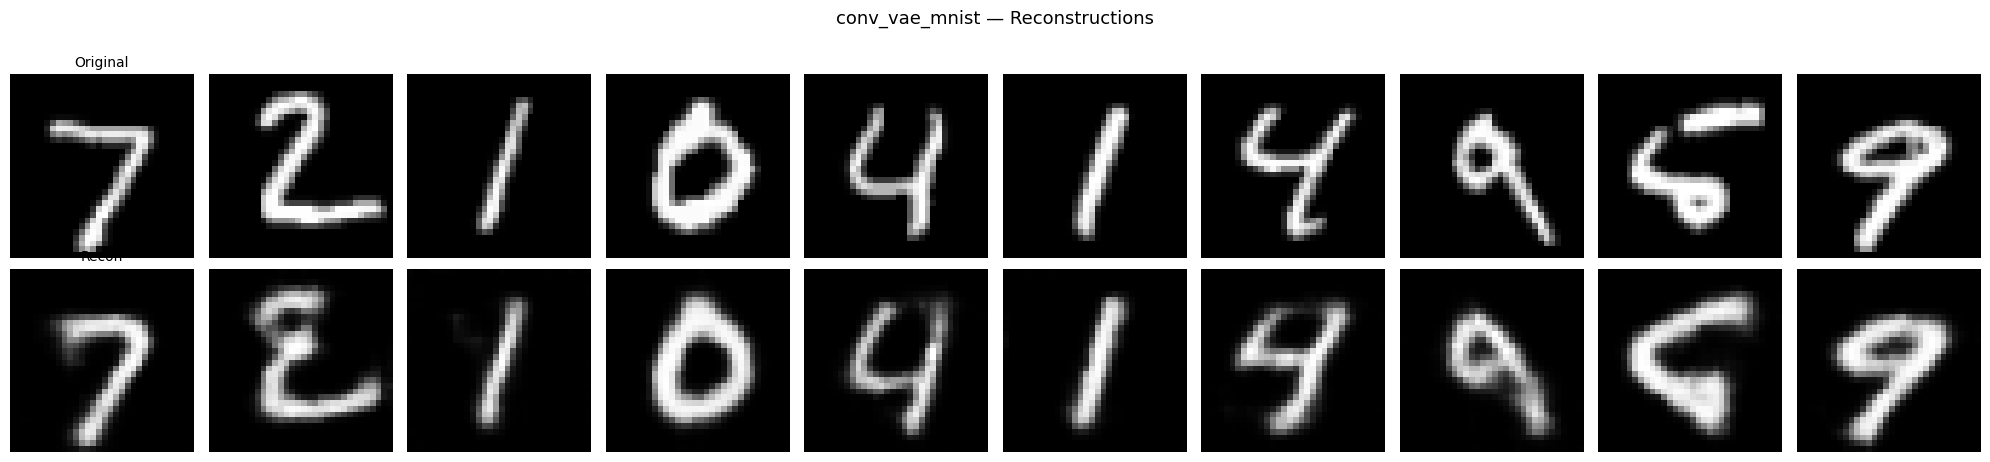

In [ ]:
# Grab a test batch
test_batch, _ = next(iter(test_loader))

plot_reconstructions(
    model,
    test_batch,
    num_images=10,
    save_path=out_dir / f'{run_name}_reconstructions.png',
    title=f'{run_name} — Reconstructions',
    show=True,
)


## 13 — Samples from Prior

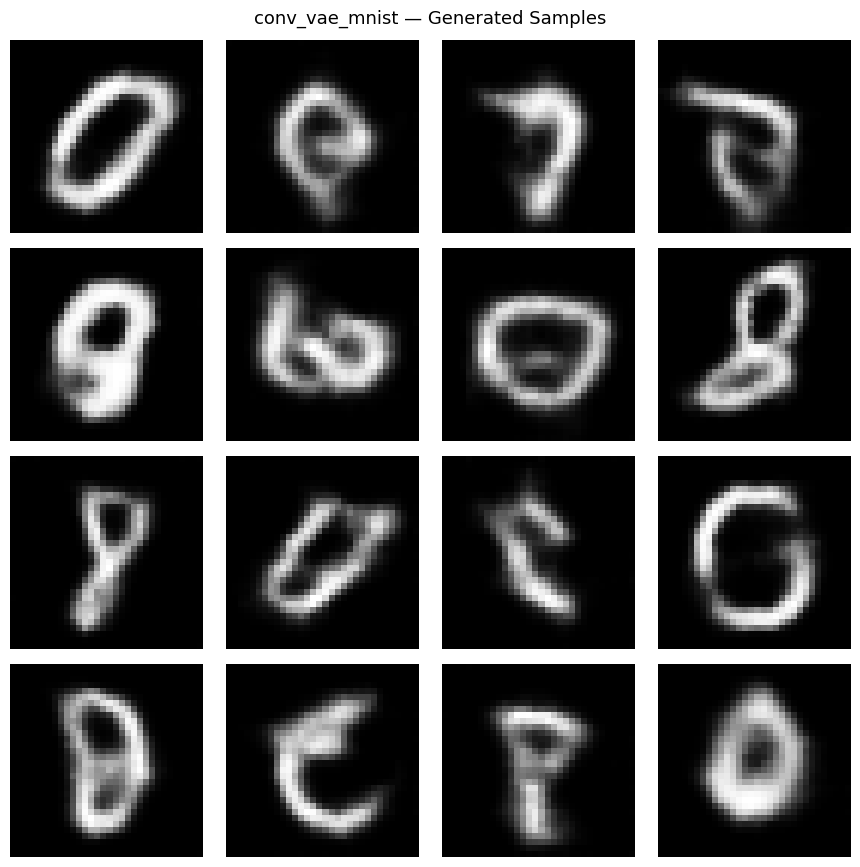

In [ ]:
plot_samples(
    model,
    num_samples=16,
    nrow=4,
    save_path=out_dir / f'{run_name}_samples.png',
    title=f'{run_name} — Generated Samples',
    show=True,
)


## 14 — Run Summary

In [ ]:
print('═' * 60)
print(f'  Model:          {run_log.model_name}')
print(f'  Dataset:        {run_log.dataset}')
print(f'  Precision:      {run_log.precision}')
print(f'  Epochs:         {run_log.epochs}')
print(f'  Best epoch:     {run_log.best_epoch}')
print(f'  Best val loss:  {run_log.best_total_loss:.4f}')
print(f'  Training time:  {run_log.total_training_time_sec:.1f}s')
print(f'  Latent dim:     {run_log.latent_dim}')
print(f'  KL weight:      {run_log.kl_weight}')
print(f'  Device:         {run_log.device}')
print('═' * 60)
print(f'\nJSON log:     {log_path}')
print(f'Best ckpt:    {ckpt_dir / f"{run_name}_best.pt"}')
print(f'Final ckpt:   {ckpt_dir / f"{run_name}_final.pt"}')
print(f'Plots:        {out_dir}')


════════════════════════════════════════════════════════════
  Model:          conv_vae
  Dataset:        mnist
  Precision:      fp32
  Epochs:         50
  Best epoch:     2
  Best val loss:  13.9313
  Training time:  948.8s
  Latent dim:     64
  KL weight:      1.0
  Device:         cuda
════════════════════════════════════════════════════════════

JSON log:     /content/drive/MyDrive/Bayes_Project/logs/conv_vae_mnist.json
Best ckpt:    /content/drive/MyDrive/Bayes_Project/models/checkpoints/conv_vae_mnist_best.pt
Final ckpt:   /content/drive/MyDrive/Bayes_Project/models/checkpoints/conv_vae_mnist_final.pt
Plots:        /content/drive/MyDrive/Bayes_Project/outputs


## (Optional) Delete unwanted checkpoints

This cell deletes all of the checkpoints which are not the final one, done so to prevent overcrowding of checkpoints

In [ ]:
from google.colab import drive
import os
import glob

checkpoint_dir = '/content/drive/MyDrive/Bayes_Project/models/checkpoints/'

all_checkpoints = glob.glob(os.path.join(checkpoint_dir, '*.pt'))

print(f"Total .pt files found: {len(all_checkpoints)}")


files_to_delete = []
for filepath in all_checkpoints:
    filename = os.path.basename(filepath)
    if not filename.endswith('_final.pt'):
        files_to_delete.append(filepath)

print(f"Unnecessary checkpoints identified for deletion: {len(files_to_delete)}\n")


print("--- DRY RUN: Files flagged for deletion ---")
for f in files_to_delete[:15]: # Prints the first 15 files as a sanity check
    print(f)

if len(files_to_delete) > 15:
    print(f"... and {len(files_to_delete) - 15} more.")
print("\nStarting deletion...")
deleted_count = 0
for filepath in files_to_delete:
    try:
        os.remove(filepath)
        deleted_count += 1
    except Exception as e:
        print(f"Error deleting {filepath}: {e}")

print(f"Cleanup complete! Successfully deleted {deleted_count} files.")

Total .pt files found: 49
Unnecessary checkpoints identified for deletion: 1

--- DRY RUN: Files flagged for deletion ---
/content/drive/MyDrive/Bayes_Project/models/checkpoints/conv_vae_mnist_final.pt

Starting deletion...
Cleanup complete! Successfully deleted 1 files.
